In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [18]:
df = pd.read_csv("./data/df_final_janeiro_22.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Freq_Depressao,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,2.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0


In [19]:
df = df.drop(columns=["Grau_Limite_DORT", "Horas_TV", "Estado_Civil", "Sexo", "Apoio_Familiar", "Grau_Limite_Depressao", "Freq_Anedonia", "Freq_Problemas_Sono", "Grau_Limite_Depressao", "Grau_Limite_Doenca_Mental"])
df

,Autoavaliacao_Saude,Idade,Cor_Raca,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,Possui_Computador,Acesso_Internet,Freq_Cansaco,Freq_Depressao,Pratica_Exercicio,Fuma,Freq_Alcool,Apoio_Amigos
0,3.0,55.0,1.0,1.0,6.0,5.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,3.0,2.0,0.0
1,2.0,19.0,4.0,1.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0
2,3.0,45.0,2.0,1.0,8.0,8.0,4.0,2.0,2.0,1.0,3.0,1.0,2.0,3.0,3.0,1.0
3,3.0,58.0,2.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,1.0,0.0
4,2.0,28.0,4.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,4.0,1.0,3.0,5.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,3.0,3.0
90842,2.0,44.0,4.0,1.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,2.0
90843,2.0,32.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0
90844,3.0,54.0,4.0,1.0,3.0,10.0,3.0,1.0,2.0,1.0,1.0,2.0,1.0,3.0,1.0,3.0


In [20]:
# target = "Saude_Boa"
target = "Autoavaliacao_Saude"

In [34]:
df['Saude_Boa'] = df['Autoavaliacao_Saude'].map({
    1: 1,  # Muito boa
    2: 1,  # Boa
    3: 0,  # Regular
    4: 0,  # Ruim
    5: 0   # Muito ruim
})
df

,Autoavaliacao_Saude,Idade,Cor_Raca,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,Possui_Computador,Acesso_Internet,Freq_Cansaco,Freq_Depressao,Diagnostico_Doenca_Cronica,Pratica_Exercicio,Fuma,Freq_Alcool,Apoio_Amigos,Saude_Boa
0,3.0,55.0,1.0,1.0,6.0,5.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,3.0,2.0,0.0,0
1,2.0,19.0,4.0,1.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1
2,3.0,45.0,2.0,1.0,8.0,8.0,4.0,2.0,2.0,1.0,3.0,1.0,2.0,2.0,3.0,3.0,1.0,0
3,3.0,58.0,2.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0,0
4,2.0,28.0,4.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,4.0,1.0,3.0,5.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,3.0,3.0,0
90842,2.0,44.0,4.0,1.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,3.0,2.0,1
90843,2.0,32.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,1.0,3.0,1.0,0.0,1
90844,3.0,54.0,4.0,1.0,3.0,10.0,3.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,3.0,0


Separando X e Y

In [21]:
X = df.drop(columns=[target, "Autoavaliacao_Saude"])
y = df[target]


Fazendo onehot encoding

In [22]:
cols_nominais = [
    'Sexo', 'Cor_Raca', 'Estado_Civil',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet',
    'Pratica_Exercicio', 'Fuma'
]

cols_nominais = [
    'Cor_Raca',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet',
    'Pratica_Exercicio', 'Fuma'
]
X = pd.get_dummies(X, columns=cols_nominais, drop_first=True)

In [97]:
cols_nominais = [
    'Sexo', 'Cor_Raca', 'Estado_Civil',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet', 'Diagnostico_Doenca_Cronica',
    'Pratica_Exercicio', 'Fuma'
]

cols_nominais = [
    'Cor_Raca',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet', 'Diagnostico_Doenca_Cronica',
    'Pratica_Exercicio', 'Fuma'
]
X = pd.get_dummies(X, columns=cols_nominais, drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

In [24]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

Utilizando CatBoostRegressor + SHAP

In [25]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="Quantile:alpha=0.5",
    eval_metric="Quantile:alpha=0.5",
    random_seed=42,
    verbose=100,
    
)

model.fit(
    X_train2,
    y_train2,
    eval_set=(X_val, y_val),
    use_best_model=True
)

y_pred = model.predict(X_test)

0:	learn: 0.2920204	test: 0.2880097	best: 0.2880097 (0)	total: 4.75ms	remaining: 3.79s
100:	learn: 0.2496306	test: 0.2480745	best: 0.2480745 (100)	total: 354ms	remaining: 2.45s
200:	learn: 0.2484549	test: 0.2475555	best: 0.2475555 (200)	total: 654ms	remaining: 1.95s
300:	learn: 0.2478508	test: 0.2472946	best: 0.2472946 (300)	total: 927ms	remaining: 1.54s
400:	learn: 0.2476118	test: 0.2472397	best: 0.2472306 (359)	total: 1.2s	remaining: 1.2s
500:	learn: 0.2475682	test: 0.2472585	best: 0.2472306 (359)	total: 1.49s	remaining: 891ms
600:	learn: 0.2475594	test: 0.2472645	best: 0.2472306 (359)	total: 1.79s	remaining: 593ms
700:	learn: 0.2475230	test: 0.2472354	best: 0.2472306 (359)	total: 2.08s	remaining: 294ms
799:	learn: 0.2475055	test: 0.2472278	best: 0.2472253 (797)	total: 2.39s	remaining: 0us

bestTest = 0.247225281
bestIteration = 797

Shrink model to first 798 iterations.


In [26]:
y_pred = model.predict(X_test)
y_pred = y_pred.clip(1, 5).round()

mae = mean_absolute_error(y_test, y_pred)
print("MAE final:", mae)


MAE final: 0.4850297204080135


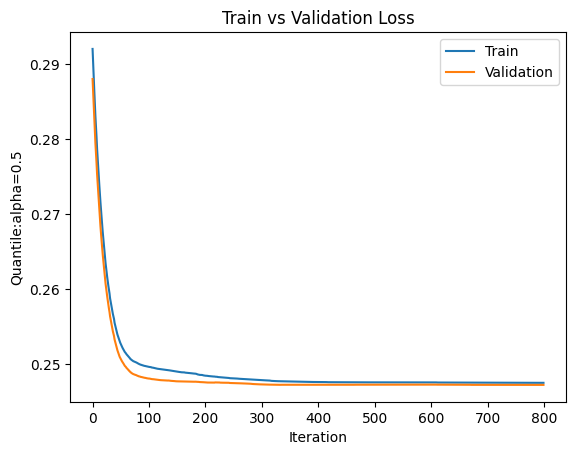

In [27]:
evals = model.get_evals_result()

train_loss = evals['learn']['Quantile:alpha=0.5']
val_loss   = evals['validation']['Quantile:alpha=0.5']

plt.figure()
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Quantile:alpha=0.5")
plt.legend()
plt.title("Train vs Validation Loss")
plt.show()


In [28]:
importances = model.get_feature_importance()
features = X_train.columns

imp_df = (
    pd.DataFrame({
        "feature": features,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

print(imp_df.head(20))


                  feature  importance
0                   Idade   25.556687
5            Freq_Cansaco   17.602455
6          Freq_Depressao   14.856469
15  Possui_Computador_2.0   11.965043
17  Pratica_Exercicio_2.0    7.159129
1         Nivel_Instrucao    7.068917
7             Freq_Alcool    5.209782
14   Possui_Automovel_2.0    3.755883
8            Apoio_Amigos    2.097654
16    Acesso_Internet_2.0    1.965136
11           Cor_Raca_4.0    0.965198
2         Total_Moradores    0.771889
4           Qtd_Banheiros    0.629483
3             Qtd_Comodos    0.319106
12           Cor_Raca_5.0    0.034113
9            Cor_Raca_2.0    0.029868
18               Fuma_2.0    0.007969
19               Fuma_3.0    0.002907
13           Cor_Raca_9.0    0.002312
10           Cor_Raca_3.0    0.000000


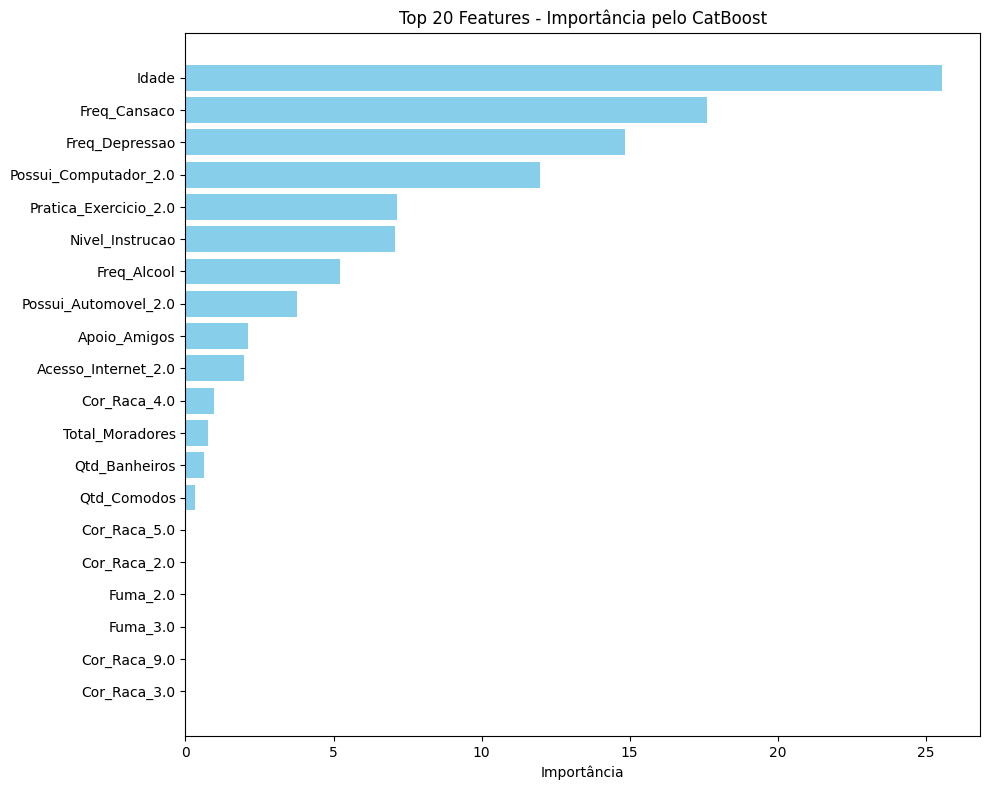

In [29]:
import matplotlib.pyplot as plt

imp_df_top20 = imp_df.head(20).sort_values("importance")

plt.figure(figsize=(10,8))
plt.barh(imp_df_top20["feature"], imp_df_top20["importance"], color="skyblue")
plt.xlabel("Importância")
plt.title("Top 20 Features - Importância pelo CatBoost")
plt.tight_layout()
plt.show()


fazendo cross validação

0:	learn: 0.2909478	test: 0.2915049	best: 0.2915049 (0)	total: 6.18ms	remaining: 4.94s
1:	learn: 0.2892070	test: 0.2896919	best: 0.2896919 (1)	total: 10.9ms	remaining: 4.36s
2:	learn: 0.2872810	test: 0.2877292	best: 0.2877292 (2)	total: 15.8ms	remaining: 4.2s
3:	learn: 0.2856439	test: 0.2861026	best: 0.2861026 (3)	total: 20.5ms	remaining: 4.08s
4:	learn: 0.2839283	test: 0.2844468	best: 0.2844468 (4)	total: 23.9ms	remaining: 3.8s
5:	learn: 0.2823099	test: 0.2827824	best: 0.2827824 (5)	total: 27.3ms	remaining: 3.61s
6:	learn: 0.2806992	test: 0.2811360	best: 0.2811360 (6)	total: 31ms	remaining: 3.51s
7:	learn: 0.2788551	test: 0.2792980	best: 0.2792980 (7)	total: 35.8ms	remaining: 3.55s
8:	learn: 0.2774574	test: 0.2778712	best: 0.2778712 (8)	total: 41.7ms	remaining: 3.67s
9:	learn: 0.2760751	test: 0.2765924	best: 0.2765924 (9)	total: 45.7ms	remaining: 3.61s
10:	learn: 0.2748326	test: 0.2753177	best: 0.2753177 (10)	total: 49ms	remaining: 3.52s
11:	learn: 0.2735160	test: 0.2740109	best: 0.27

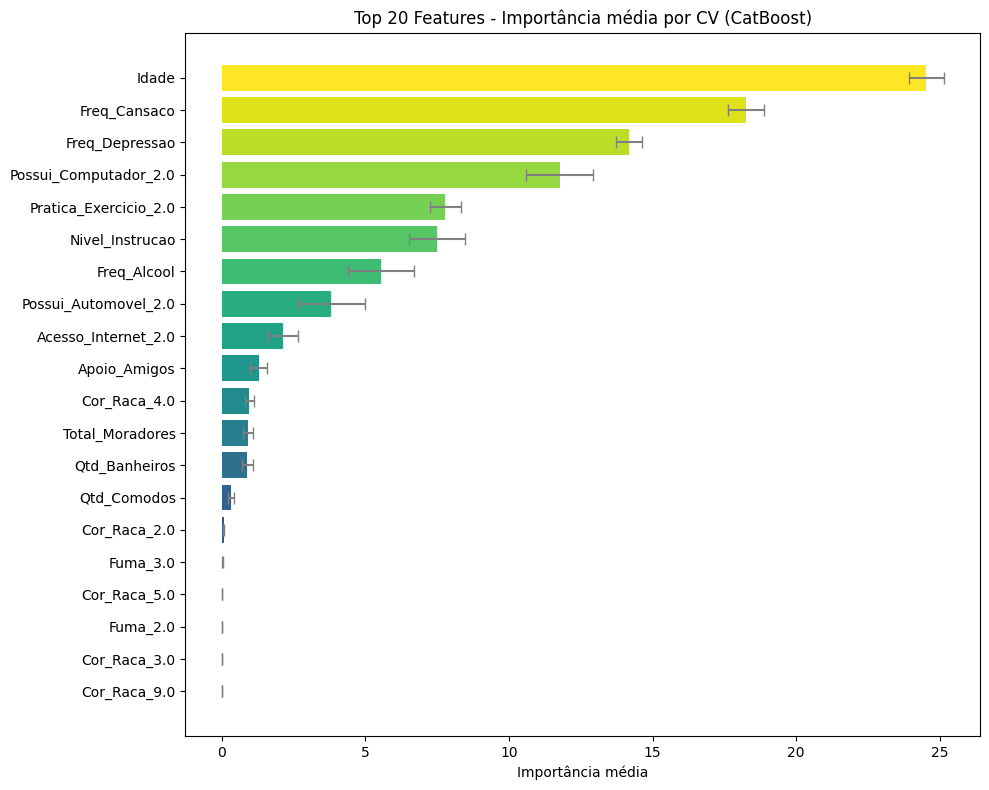

In [30]:
params = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': 'Quantile:alpha=0.5',
    'eval_metric': 'Quantile:alpha=0.5',
    'random_seed': 42,
    'verbose': True
}


n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

feature_importances = []
fold = 1

for train_index, val_index in kf.split(X):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    model = CatBoostRegressor(**params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        use_best_model=True,
    )

    importances = model.get_feature_importance()
    feature_importances.append(importances)
    best_iter = model.get_best_iteration()
    best_score = model.get_best_score()['validation']['Quantile:alpha=0.5']

    print(f"Fold {fold}: Melhor iteração = {best_iter}, Melhor loss no eval_set = {best_score:.4f}")
    fold += 1

# Média e desvio padrão das importâncias
importances_mean = np.mean(feature_importances, axis=0)
importances_std = np.std(feature_importances, axis=0)

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': importances_mean,
    'importance_std': importances_std
}).sort_values('importance_mean', ascending=False)

top20 = imp_df.head(20).sort_values('importance_mean')

colors = cm.viridis(np.linspace(0, 1, len(top20)))

plt.figure(figsize=(10,8))
plt.barh(
    top20['feature'],
    top20['importance_mean'],
    xerr=top20['importance_std'],
    color=colors,
    ecolor='gray',
    capsize=4
)
plt.xlabel('Importância média')
plt.title('Top 20 Features - Importância média por CV (CatBoost)')
plt.gca()
plt.tight_layout()
plt.show()


Fazendo Clusterização com as melhores Variáveis do SHAP

In [130]:
features_cluster = [
    "Diagnostico_Doenca_Cronica",
    "Idade",
    "Freq_Cansaco",
    "Pratica_Exercicio",
    "Freq_Depressao",
    "Freq_Problemas_Sono",
    "Nivel_Instrucao",
    "Freq_Alcool",
    "Freq_Anedonia",
    "Possui_Computador",
    "Possui_Automovel"
]

X_cluster = df[features_cluster]

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Utilizando K-means

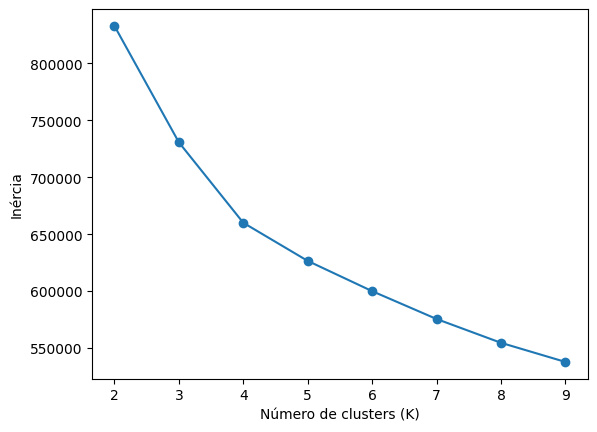

In [132]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.show()


In [136]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts()

cluster
3    29678
1    24570
0    23377
2    13221
Name: count, dtype: int64

In [137]:
cluster_profile = (
    df.groupby("cluster")[features_cluster]
      .mean()
      .round(2)
)

cluster_profile

,Diagnostico_Doenca_Cronica,Idade,Freq_Cansaco,Pratica_Exercicio,Freq_Depressao,Freq_Problemas_Sono,Nivel_Instrucao,Freq_Alcool,Freq_Anedonia,Possui_Computador,Possui_Automovel
cluster,,,,,,,,,,,
0,1.13,64.15,1.36,1.77,1.25,1.68,1.80,1.25,1.22,1.86,1.71
1,1.51,41.69,1.39,1.32,1.17,1.42,1.17,1.94,1.20,1.06,1.19
2,1.21,46.51,3.08,1.69,2.68,3.02,1.42,1.56,2.75,1.68,1.64
3,1.84,36.25,1.28,1.65,1.18,1.25,1.19,1.79,1.19,1.94,1.76


In [138]:
import pandas as pd

crosstab_norm = pd.crosstab(
    df["cluster"],
    df["Autoavaliacao_Saude"],
    normalize="index"
)

crosstab_norm.round(3)


Autoavaliacao_Saude,1.0,2.0,3.0,4.0,5.0
cluster,,,,,
0,0.050,0.373,0.470,0.092,0.016
1,0.247,0.579,0.163,0.009,0.001
2,0.050,0.284,0.454,0.159,0.054
3,0.138,0.611,0.233,0.015,0.002
